# Minimum Profit Optimization

In [17]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
# If you're running the notebook from a subfolder, walk up until we find "data"
while not (PROJECT_ROOT / "data").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [114]:
import numpy as np
import pandas as pd

from src.cointegration.simulation import CointegrationSimulation
from src.cointegration.minimum_profit import MinimumProfit
from src.trading.minimum_profit import TradingMinimumProfit
from src.visual.main import plot_trades
from src.backtesting.pairs_trading import PairsTrading

## Data Simulation
We first demonstrate how we can simulate cointegrated data

In [19]:
# Initialize the data simulator
# Generate 20 cointegrated series, each of the series have 250 data points
coint_simulator = CointegrationSimulation(20, 250)

In [20]:
# Set the parameters for e_t
price_params = {
    "ar_coeff": 0.95,
    "white_noise_var": 0.5,
    "constant_trend": 1.5
}

# Set the parameters for epsilon_t
coint_params = {
    "ar_coeff": 0.9,
    "white_noise_var": 1.,
    "constant_trend": 0.05,
    "beta": -0.6
}

# Load the parameters
coint_simulator.load_params(price_params, target='price')
coint_simulator.load_params(coint_params, target='coint')

In [21]:
# Using statsmodels package to simulate the cointegrated series
s1_series, s2_series, coint_errors = coint_simulator.simulate_coint(initial_price=100.)

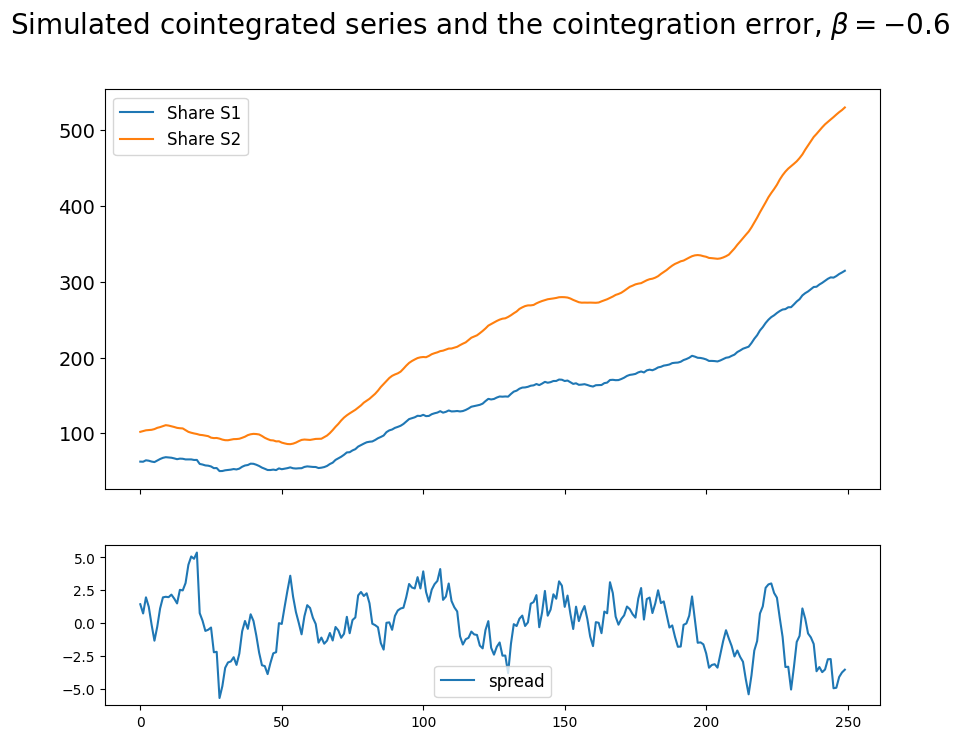

In [22]:
# Plot an example of the simulated cointegrated series and cointegration error
coint_sim_fig = coint_simulator.plot(s1_series[:, 0], s2_series[:, 0], coint_errors[:, 0], 10, 8)

## Mininum Profit Optmization

Demonstrate the trading strategy wtih empirical data

<Axes: xlabel='Date'>

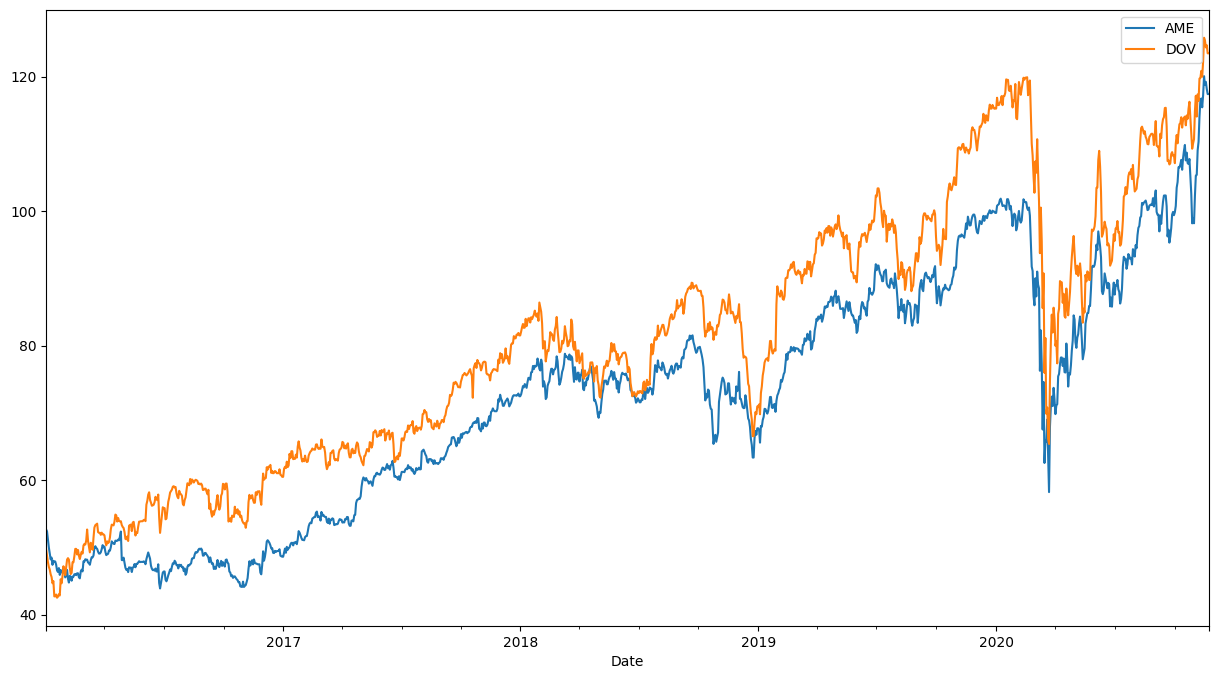

In [103]:
data = pd.read_csv('../data/sample-data/AME-DOV.csv', parse_dates = ['Date'])
data.set_index('Date', inplace = True)
data.plot(figsize = (15, 8))

In [24]:
# Split the entire price history into training and trading period
# 2019 Jan 1st was a market holiday so it is a perfect split point
train_df = data[data.index < pd.Timestamp(2019, 1, 1)]
trade_df = data[data.index >= pd.Timestamp(2019, 1, 1)]

In [26]:
optimizer = MinimumProfit()
optimizer.set_train_dataset(train_df)

In [33]:
beta_eg, epsilon_t_eg, ar_coeff_eg, ar_resid_eg = optimizer.fit(use_johansen = False, sig_level="95%")

print("The cointegration coefficient is: {}".format(beta_eg))
print("The AR(1) coefficient of the cointegration error is: {}".format(ar_coeff_eg))

sigma_e = epsilon_t_eg.std()
sigma_a = ar_resid_eg.std()

print("The standard deviation of the cointegration error is: {}".format(sigma_e))
print("The standard deviation of the fitted AR(1) process residual is: {}".format(sigma_a))
print("The ratio of the AR(1) residual std-dev to "
      "cointegration error std-dev is: {}".format(sigma_a / sigma_e))
print("Value of sqrt(1 - phi^2) is: {}".format(np.sqrt(1 - ar_coeff_eg ** 2)))

The cointegration coefficient is: -0.9492880699578974
The AR(1) coefficient of the cointegration error is: 0.9831130427304122
The standard deviation of the cointegration error is: 3.7157992242760254
The standard deviation of the fitted AR(1) process residual is: 0.7850483334535239
The ratio of the AR(1) residual std-dev to cointegration error std-dev is: 0.2112730764150693
Value of sqrt(1 - phi^2) is: 0.18299930386028976


In [39]:
# Optimize the pre-set boundaries based on the fitted parameters
optimal_ub, _, _, optimal_mtp, optimal_num_of_trades = optimizer.optimize(ar_coeff_eg, epsilon_t_eg, ar_resid_eg, len(train_df))

Progress: |██████████████████████████████████████████████████| 100.0% Complete


In [40]:
print("The optimal upper-bound is: {}".format(optimal_ub))
print("The optimal minimal total profit over the in-sample period with only U-trades: ${:.2f}".format(optimal_mtp))
print("The optimal total number of U-trades is: {}".format(np.floor(optimal_num_of_trades)))
print("The optimal minimal total profit over the in-sample period with both "
      "U-trades and L-trades: ${:.2f}".format(2. * optimal_mtp))
print("The optimal total number of U-trades and L-trades is: {}".format(2. * np.floor(optimal_num_of_trades)))

The optimal upper-bound is: 2.05
The optimal minimal total profit over the in-sample period with only U-trades: $14.92
The optimal total number of U-trades is: 7.0
The optimal minimal total profit over the in-sample period with both U-trades and L-trades: $29.84
The optimal total number of U-trades and L-trades is: 14.0


## Trading Strategy

In [43]:
# Obtain levels to open and close trades and number of shares to trade on in-sample data
num_of_shares_is, trading_levels_is = optimizer.get_optimal_levels(optimal_ub, optimal_mtp, 
                                                                   beta_eg, epsilon_t_eg)

# Show the number of shares to trade
print("The number of AME and DOV shares to trade is", num_of_shares_is)
# Show the entry and exit levels
print("The trading levels for the AME and DOV shares spread are", trading_levels_is)

The number of AME and DOV shares to trade is [8. 7.]
The trading levels for the AME and DOV shares spread are [-5.49093964 -3.44093964 -1.39093964]


In [44]:
# Construct spread values
spread = optimizer.construct_spread(trade_df, beta_eg)

<Axes: xlabel='Date'>

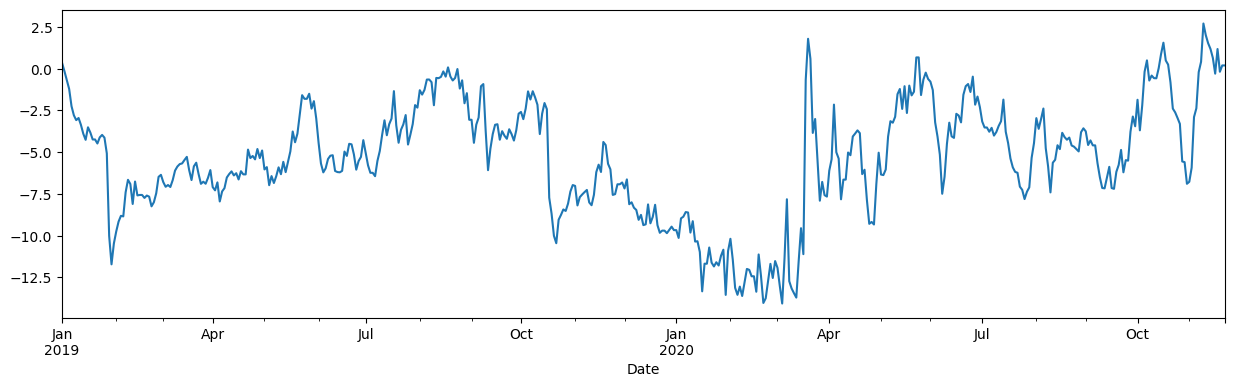

In [67]:
spread.plot(figsize=(15, 4))

In [48]:
strategy = TradingMinimumProfit(shares = num_of_shares_is, optimal_levels = trading_levels_is)

In [50]:
# Adding initial spread value
strategy.update_spread_value(spread[0])

# Feeding spread values to the strategy one by one
for time, value in spread.items():
    strategy.update_spread_value(value)

    # Checking if logic for opening a trade is triggered
    trade, side = strategy.check_entry_signal()

    # Adding a trade if we decide to trade signal
    if trade:
        strategy.add_trade(start_timestamp=time, side_prediction=side)

    # Update trades, close if logic is triggered
    close = strategy.update_trades(update_timestamp=time)

/var/folders/bc/hnzwjdn546lcc572zg36k_vc0000gn/T/ipykernel_50647/970828861.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  strategy.update_spread_value(spread[0])


In [51]:
# Currently open trades in a strategy
open_trades = strategy.open_trades

open_trades

{Timestamp('2020-11-06 00:00:00'): {'exit_level': np.float64(-3.440939638219148),
  'start_value': -0.1961171044984269,
  'spread_series': [-2.9479681226078753,
   -3.3030842038034507,
   -5.557693165698609,
   -5.5971236216649345,
   -6.8956822250388115,
   -6.774720596063688,
   -5.9285902762672436,
   -2.8952901400973445,
   -2.367940770958427,
   -0.1961171044984269],
  'uuid': None,
  'side': -1,
  'shares': None,
  'latest_update_timestamp': Timestamp('2020-11-23 00:00:00')}}

In [52]:
# Checking all closed trades
closed_trades = strategy.closed_trades

closed_trades

{Timestamp('2019-01-01 00:00:00'): {'t1': Timestamp('2019-01-14 00:00:00'),
  'pt': -3.8914267409134737,
  'uuid': None,
  'start_value': 0.3480114364871838,
  'end_value': -3.8914267409134737,
  'side': -1},
 Timestamp('2019-01-29 00:00:00'): {'t1': Timestamp('2019-05-22 00:00:00'),
  'pt': -2.7117620288827737,
  'uuid': None,
  'start_value': -10.02066010757244,
  'end_value': -2.7117620288827737,
  'side': 1},
 Timestamp('2019-06-04 00:00:00'): {'t1': Timestamp('2019-07-11 00:00:00'),
  'pt': -3.088994269989513,
  'uuid': None,
  'start_value': -5.676993144437304,
  'end_value': -3.088994269989513,
  'side': 1},
 Timestamp('2019-07-17 00:00:00'): {'t1': Timestamp('2019-07-19 00:00:00'),
  'pt': -4.434145424268905,
  'uuid': None,
  'start_value': -1.3390391581808814,
  'end_value': -4.434145424268905,
  'side': -1},
 Timestamp('2019-08-01 00:00:00'): {'t1': Timestamp('2019-09-03 00:00:00'),
  'pt': -4.438639351805094,
  'uuid': None,
  'start_value': -1.283300923325939,
  'end_value

<Axes: >

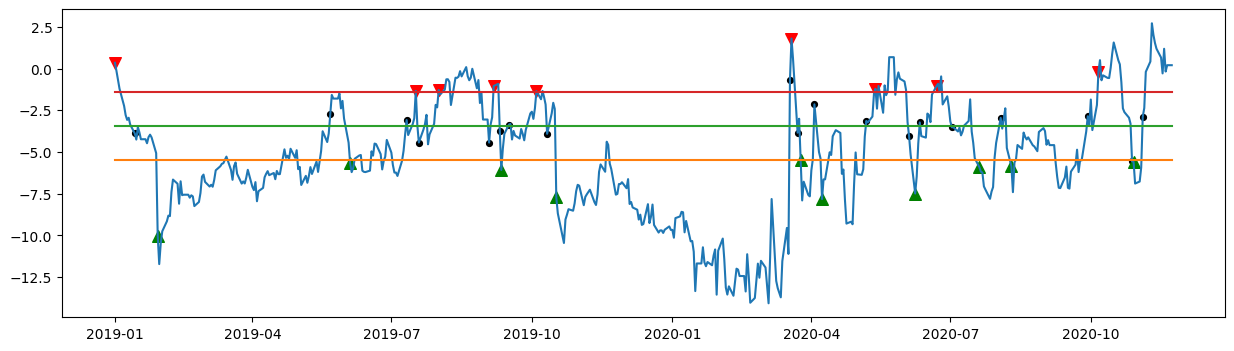

In [85]:
plot_trades(spread, trading_levels_is, closed_trades, (15, 4))

In [124]:

positions = pd.Series(0, index = spread.index, dtype = 'int64')
for entry, trade in closed_trades.items():
    exit = trade['t1']
    side = trade['side']
    positions[entry:exit] = side

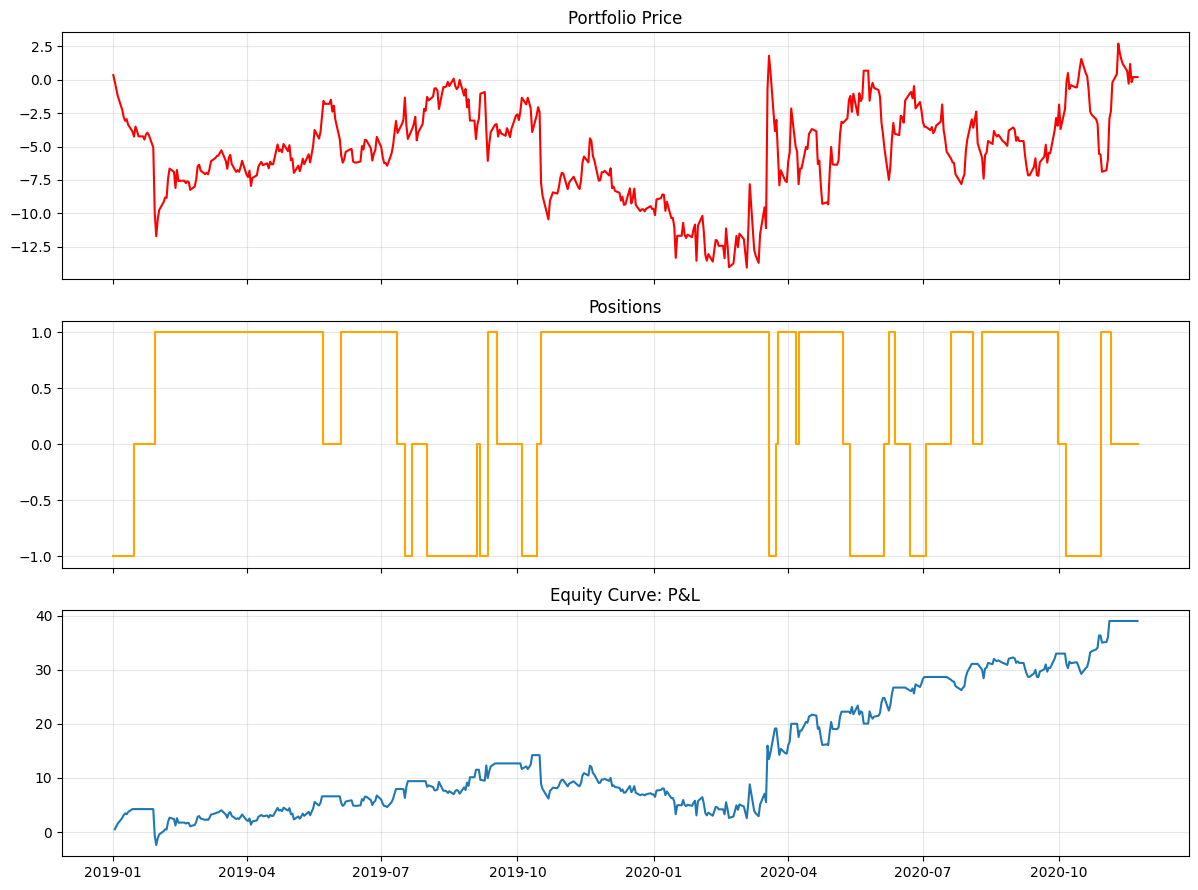

In [125]:
backtest = PairsTrading(spread, positions)
backtest.plot_stratgy();